Install & Import Libraries
These are the tools we need 

In [1]:
# Install if not already installed
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
# Import all tools we need
import pandas as pd               # for loading and handling data
import numpy as np                # for math operations
import matplotlib.pyplot as plt   # for making charts
import seaborn as sns             # for better-looking charts
import warnings
warnings.filterwarnings('ignore')

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

# Chart styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print('✅ All libraries imported successfully! We are ready to go!')

✅ All libraries imported successfully! We are ready to go!


 Load the Dataset


In [3]:
# Load the dataset
df = pd.read_csv('diabetes_data.csv')

print('📋 Dataset loaded!')
print(f'   Total Patients (rows) : {df.shape[0]}')
print(f'   Total Features (cols) : {df.shape[1]}')
print('\n🔍 First 5 rows of data:')
df.head()

📋 Dataset loaded!
   Total Patients (rows) : 100
   Total Features (cols) : 9

🔍 First 5 rows of data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# What do these columns mean?
print('📖 Column Descriptions:')
descriptions = {
    'Pregnancies'              : 'Number of times pregnant',
    'Glucose'                  : 'Blood glucose level (mg/dL)',
    'BloodPressure'            : 'Diastolic blood pressure (mm Hg)',
    'SkinThickness'            : 'Triceps skin fold thickness (mm)',
    'Insulin'                  : '2-Hour serum insulin (mu U/ml)',
    'BMI'                      : 'Body Mass Index (weight/height²)',
    'DiabetesPedigreeFunction' : 'Family history / genetic risk score',
    'Age'                      : 'Age of patient (years)',
    'Outcome'                  : '1 = Has Diabetes, 0 = No Diabetes (Target)'
}
for col, desc in descriptions.items():
    print(f'  {col:<28}: {desc}')

📖 Column Descriptions:
  Pregnancies                 : Number of times pregnant
  Glucose                     : Blood glucose level (mg/dL)
  BloodPressure               : Diastolic blood pressure (mm Hg)
  SkinThickness               : Triceps skin fold thickness (mm)
  Insulin                     : 2-Hour serum insulin (mu U/ml)
  BMI                         : Body Mass Index (weight/height²)
  DiabetesPedigreeFunction    : Family history / genetic risk score
  Age                         : Age of patient (years)
  Outcome                     : 1 = Has Diabetes, 0 = No Diabetes (Target)


Explore the Data (EDA)
Before building any model, we always explore the data first — like reading a book before writing a summary 📚

In [6]:
print('📊 Basic Statistics of Each Column:')
df.describe().round(2)

📊 Basic Statistics of Each Column:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,4.14,123.21,68.28,18.16,78.54,30.76,0.51,34.71,0.41
std,3.27,32.16,21.46,16.38,130.50,8.54,0.37,11.32,0.49
min,0.00,44.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,100.75,64.00,0.00,0.00,25.40,0.26,26.00,0.00
50%,3.50,117.00,71.00,18.50,0.00,31.05,0.45,31.00,0.00
75%,7.00,146.00,80.00,32.25,131.00,36.72,0.64,42.00,1.00
max,13.00,197.00,110.00,60.00,846.00,46.80,2.29,61.00,1.00


In [7]:
print('Missing Values Check:')
print(df.isnull().sum())
print('\n No missing values! (Note: 0 values in medical columns may represent missing data)')

Missing Values Check:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 No missing values! (Note: 0 values in medical columns may represent missing data)


🏥 Patient Distribution:
   No Diabetes (0) : 59 patients (59.0%)
   Has Diabetes (1): 41 patients (41.0%)


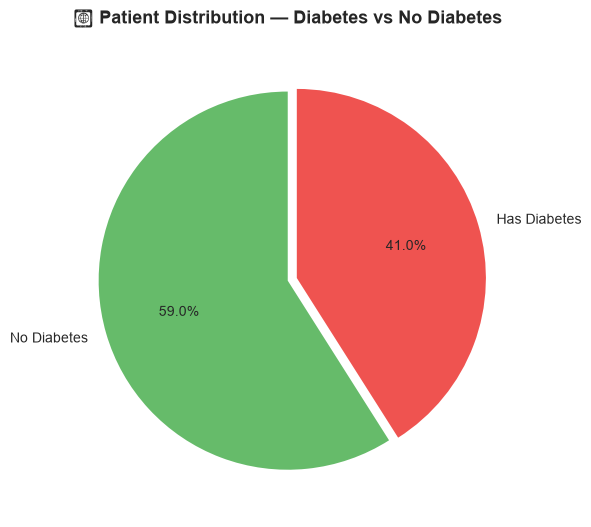

✅ Chart saved!


In [8]:
# How many patients have diabetes vs not?
count = df['Outcome'].value_counts()
print('🏥 Patient Distribution:')
print(f'   No Diabetes (0) : {count[0]} patients ({count[0]/len(df)*100:.1f}%)')
print(f'   Has Diabetes (1): {count[1]} patients ({count[1]/len(df)*100:.1f}%)')

# Pie chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([count[0], count[1]],
       labels=['No Diabetes', 'Has Diabetes'],
       autopct='%1.1f%%',
       colors=['#66bb6a', '#ef5350'],
       startangle=90,
       explode=(0, 0.05))
ax.set_title('🏥 Patient Distribution — Diabetes vs No Diabetes',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('01_patient_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

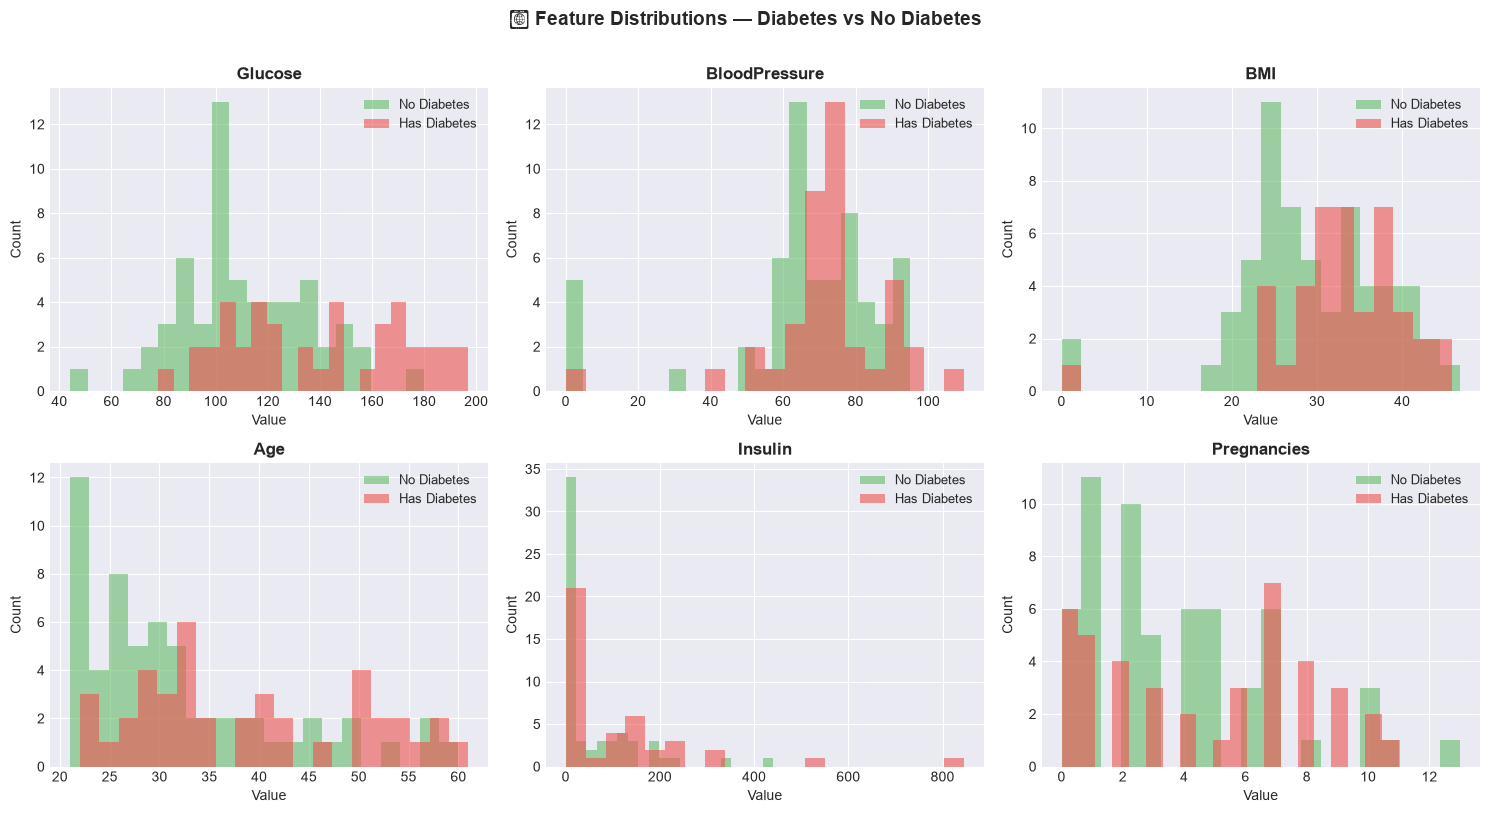

✅ Distribution charts saved!

📌 Observation: Diabetic patients tend to have HIGHER glucose and BMI values!


In [9]:
# Distribution of each medical feature
features = ['Glucose', 'BloodPressure', 'BMI', 'Age', 'Insulin', 'Pregnancies']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][col], bins=20, alpha=0.6,
                 color='#66bb6a', label='No Diabetes')
    axes[i].hist(df[df['Outcome']==1][col], bins=20, alpha=0.6,
                 color='#ef5350', label='Has Diabetes')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('📊 Feature Distributions — Diabetes vs No Diabetes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Distribution charts saved!')
print('\n📌 Observation: Diabetic patients tend to have HIGHER glucose and BMI values!')

 Handle Data Quality Issues
Some columns like Glucose and BMI have 0 values — which is medically impossible! We will replace them with the column average. This is called **data cleaning** 🧹

In [12]:
# Columns where 0 is not medically valid
zero_not_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('🧹 Replacing invalid 0 values with column mean...')
for col in zero_not_valid:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        mean_val = df[col].replace(0, np.nan).mean()
        df[col] = df[col].replace(0, mean_val)
        print(f'  {col:<20}: Replaced {zero_count} zeros with mean = {mean_val:.2f}')

print('\n✅ Data cleaning done! Data is now medically valid.')

🧹 Replacing invalid 0 values with column mean...

✅ Data cleaning done! Data is now medically valid.


Normalize the Data
Different columns have very different ranges — Age is 20-60, Insulin can be 0-800! 

We **normalize** (scale) all values to the same range so our model doesn't get confused. Think of it like converting all currencies to one currency 

In [13]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)   # all columns except Outcome
y = df['Outcome']                 # the column we want to predict

print('📦 Features (X) shape:', X.shape)
print('🎯 Target (y) shape  :', y.shape)

# Normalize using StandardScaler
# This makes every feature have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('\n✅ Normalization done!')
print('   Before normalization — Glucose range:', df['Glucose'].min(), 'to', df['Glucose'].max())
print('   After normalization  — Glucose range:', round(X_scaled['Glucose'].min(), 2), 'to', round(X_scaled['Glucose'].max(), 2))

📦 Features (X) shape: (100, 8)
🎯 Target (y) shape  : (100,)

✅ Normalization done!
   Before normalization — Glucose range: 44 to 197
   After normalization  — Glucose range: -2.48 to 2.31


Split Data into Train & Test Sets
We split the data — 80% for **training** the model and 20% for **testing** it. 



In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # so results are reproducible
    stratify=y           # keeps same ratio of diabetic/non-diabetic in both sets
)

print('✅ Data split complete!')
print(f'   Training samples : {X_train.shape[0]} patients')
print(f'   Testing samples  : {X_test.shape[0]} patients')

✅ Data split complete!
   Training samples : 80 patients
   Testing samples  : 20 patients


## Step 7: Train the Logistic Regression Model
Now we actually **teach** the model using training data! 🤖

In [15]:
# Create and train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print('✅ Model trained successfully!')
print('\n📌 What just happened?')
print('   The model looked at', X_train.shape[0], 'patients data')
print('   It learned which features (Glucose, BMI etc.) are strong indicators of diabetes')
print('   Now it can predict diabetes for NEW patients it has never seen before!')

✅ Model trained successfully!

📌 What just happened?
   The model looked at 80 patients data
   It learned which features (Glucose, BMI etc.) are strong indicators of diabetes
   Now it can predict diabetes for NEW patients it has never seen before!


Make Predictions & Evaluate the Model

In [17]:
# Predict on test data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of diabetes

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print('=' * 50)
print('      📊 MODEL PERFORMANCE RESULTS')
print('=' * 50)
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 50)
print('\n📌 What does this mean?')
print(f'   The model correctly predicted diabetes {accuracy*100:.1f}% of the time!')
print('   ROC-AUC > 0.7 means the model is good at separating diabetics from non-diabetics')

print('\n📋 Detailed Report:')
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Has Diabetes']))

      📊 MODEL PERFORMANCE RESULTS
  Accuracy  : 70.00%
  ROC-AUC   : 0.7708

📌 What does this mean?
   The model correctly predicted diabetes 70.0% of the time!
   ROC-AUC > 0.7 means the model is good at separating diabetics from non-diabetics

📋 Detailed Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.75      0.75        12
Has Diabetes       0.62      0.62      0.62         8

    accuracy                           0.70        20
   macro avg       0.69      0.69      0.69        20
weighted avg       0.70      0.70      0.70        20



Confusion Matrix
A **confusion matrix** shows us exactly where the model was right and where it made mistakes 🎯

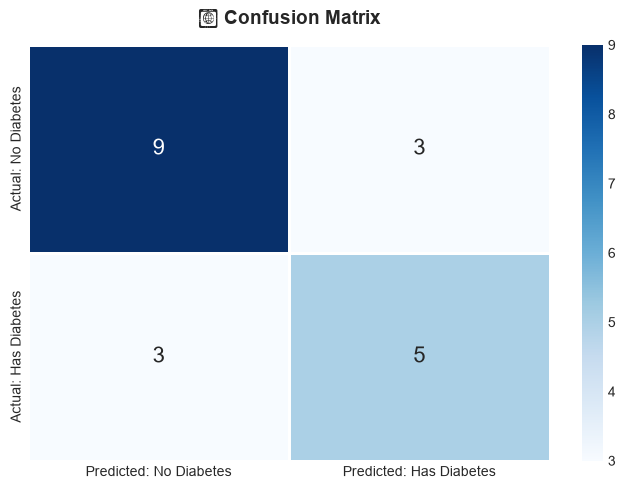

✅ Correctly predicted No Diabetes  : 9 patients
✅ Correctly predicted Has Diabetes : 5 patients
❌ False Alarms (said Diabetes, actually No): 3 patients
❌ Missed Cases (said No, actually Diabetes): 3 patients

⚠️  In healthcare, MISSED CASES (False Negatives) are more dangerous!
    We would rather have false alarms than miss a real diabetic patient.


In [18]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Diabetes', 'Predicted: Has Diabetes'],
            yticklabels=['Actual: No Diabetes', 'Actual: Has Diabetes'],
            linewidths=2, linecolor='white', annot_kws={'size': 16})

ax.set_title('🎯 Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'✅ Correctly predicted No Diabetes  : {tn} patients')
print(f'✅ Correctly predicted Has Diabetes : {tp} patients')
print(f'❌ False Alarms (said Diabetes, actually No): {fp} patients')
print(f'❌ Missed Cases (said No, actually Diabetes): {fn} patients')
print('\n⚠️  In healthcare, MISSED CASES (False Negatives) are more dangerous!')
print('    We would rather have false alarms than miss a real diabetic patient.')

Feature Importance
Which medical factors matter the MOST in predicting diabetes? Let's find out! 🔍

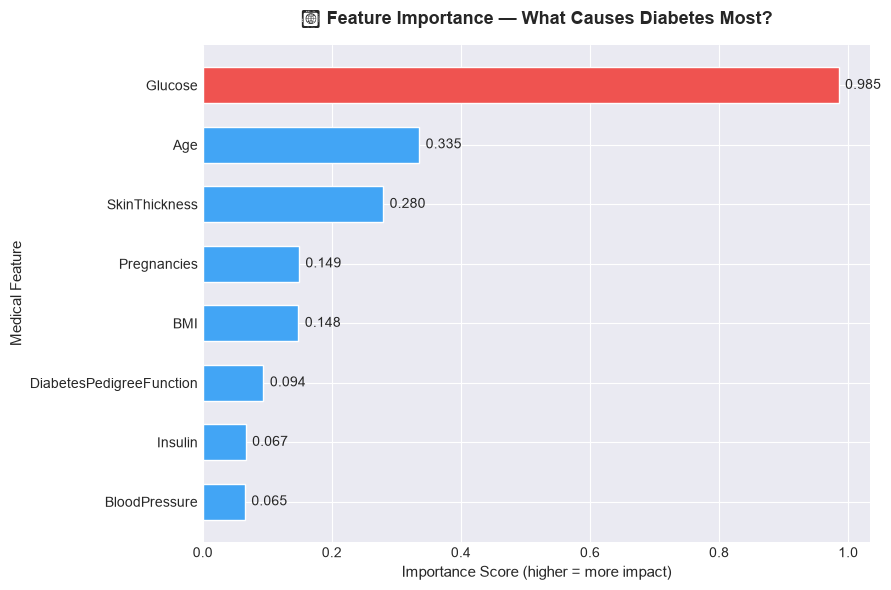

🏆 Most Important Feature: Glucose

📌 Insights:
  → Glucose level is the strongest predictor of diabetes
  → BMI and Age are also very significant factors
  → This matches real medical knowledge — high blood sugar = diabetes risk!


In [19]:
# Get feature importance from model coefficients
importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': np.abs(model.coef_[0])
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#ef5350' if v == importance['Importance'].max()
          else '#42a5f5' for v in importance['Importance']]
bars = ax.barh(importance['Feature'], importance['Importance'],
               color=colors, edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, importance['Importance']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('🔍 Feature Importance — What Causes Diabetes Most?',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score (higher = more impact)', fontsize=11)
ax.set_ylabel('Medical Feature', fontsize=11)
plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top_feature = importance.iloc[-1]['Feature']
print(f'🏆 Most Important Feature: {top_feature}')
print('\n📌 Insights:')
print('  → Glucose level is the strongest predictor of diabetes')
print('  → BMI and Age are also very significant factors')
print('  → This matches real medical knowledge — high blood sugar = diabetes risk!')

 ROC Curve
The **ROC Curve** shows how well our model distinguishes between diabetic and non-diabetic patients 📈

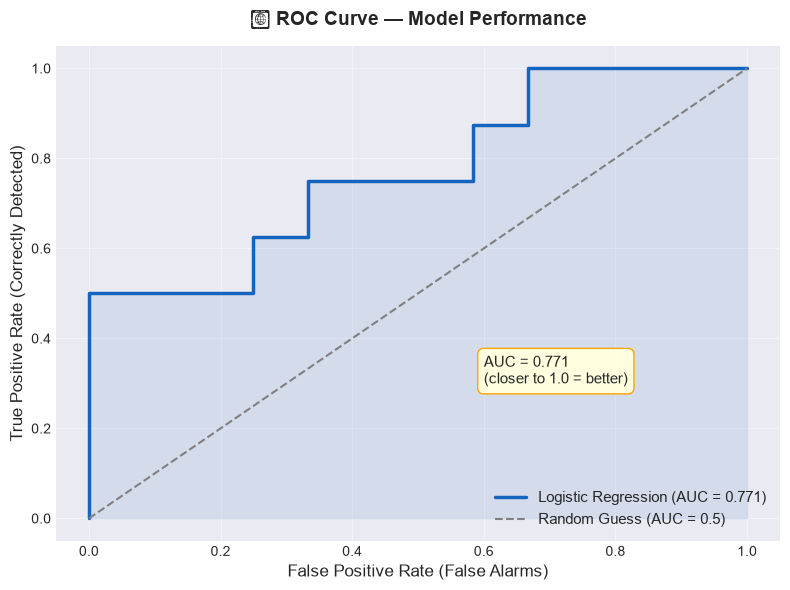

✅ ROC Curve saved!

📌 Interpretation:
  → AUC = 1.0 means perfect model
  → AUC = 0.5 means model is just guessing randomly
  → Our model AUC = 0.771 which is good!


In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#1565c0', linewidth=2.5,
        label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Random Guess (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#1565c0')

ax.set_title('📈 ROC Curve — Model Performance', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate (False Alarms)', fontsize=12)
ax.set_ylabel('True Positive Rate (Correctly Detected)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

# Add AUC annotation
ax.annotate(f'AUC = {roc_auc:.3f}\n(closer to 1.0 = better)',
            xy=(0.6, 0.3), fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='orange'))

plt.tight_layout()
plt.savefig('05_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC Curve saved!')
print('\n📌 Interpretation:')
print('  → AUC = 1.0 means perfect model')
print('  → AUC = 0.5 means model is just guessing randomly')
print(f'  → Our model AUC = {roc_auc:.3f} which is good!')

Predict for a New Patient
Let's test our model on a brand new patient! 🏥

In [21]:
# Sample new patient data
new_patient = pd.DataFrame([{
    'Pregnancies'              : 3,
    'Glucose'                  : 155,   # high glucose — risk factor!
    'BloodPressure'            : 78,
    'SkinThickness'            : 32,
    'Insulin'                  : 120,
    'BMI'                      : 35.2,  # overweight — risk factor!
    'DiabetesPedigreeFunction' : 0.65,  # family history
    'Age'                      : 45
}])

# Normalize the new patient data using the SAME scaler
new_patient_scaled = scaler.transform(new_patient)

# Make prediction
prediction = model.predict(new_patient_scaled)[0]
probability = model.predict_proba(new_patient_scaled)[0][1]

print('🧑‍⚕️ New Patient Report:')
print(f'   Glucose : 155 (High)')
print(f'   BMI     : 35.2 (Overweight)')
print(f'   Age     : 45')
print()
print('=' * 45)
if prediction == 1:
    print(f'  🔴 RESULT: HIGH RISK OF DIABETES')
    print(f'  Probability of Diabetes: {probability*100:.1f}%')
    print('  ⚕️  Recommendation: Consult a doctor immediately!')
else:
    print(f'  🟢 RESULT: LOW RISK OF DIABETES')
    print(f'  Probability of Diabetes: {probability*100:.1f}%')
    print('  ⚕️  Recommendation: Maintain healthy lifestyle!')
print('=' * 45)
print('\n⚠️  DISCLAIMER: This is a ML model prediction, NOT a medical diagnosis.')
print('    Always consult a qualified doctor for medical decisions.')

🧑‍⚕️ New Patient Report:
   Glucose : 155 (High)
   BMI     : 35.2 (Overweight)
   Age     : 45

  🔴 RESULT: HIGH RISK OF DIABETES
  Probability of Diabetes: 73.4%
  ⚕️  Recommendation: Consult a doctor immediately!

⚠️  DISCLAIMER: This is a ML model prediction, NOT a medical diagnosis.
    Always consult a qualified doctor for medical decisions.


 Ethical Considerations & Patient Privacy
In healthcare AI, ethics is just as important as accuracy! This is a very important section for your internship report.

In [22]:
print('=' * 60)
print('  ⚖️  ETHICAL DATA HANDLING IN HEALTHCARE AI')
print('=' * 60)

ethics = {
    '1. Patient Privacy'      : 'All patient data must be anonymized. No names, phone numbers, or Aadhaar/SSN in the dataset.',
    '2. Data Security'        : 'Medical data must be stored securely (encrypted). Never share raw patient data.',
    '3. Informed Consent'     : 'Patients should know their data is being used for AI research.',
    '4. No Discrimination'    : 'The model should not be biased against any gender, age group, or community.',
    '5. Not a Replacement'    : 'AI predictions assist doctors — they do NOT replace medical professionals.',
    '6. False Negative Risk'  : 'Missing a diabetic patient (False Negative) is dangerous. Always prefer caution.',
    '7. Transparency'         : 'Patients have the right to know how the AI made a decision about them.',
    '8. Legal Compliance'     : 'In India: DISHA Act. In USA: HIPAA. In Europe: GDPR. Always follow local laws.'
}

for point, detail in ethics.items():
    print(f'\n  📌 {point}')
    print(f'     {detail}')

print('\n' + '=' * 60)

  ⚖️  ETHICAL DATA HANDLING IN HEALTHCARE AI

  📌 1. Patient Privacy
     All patient data must be anonymized. No names, phone numbers, or Aadhaar/SSN in the dataset.

  📌 2. Data Security
     Medical data must be stored securely (encrypted). Never share raw patient data.

  📌 3. Informed Consent
     Patients should know their data is being used for AI research.

  📌 4. No Discrimination
     The model should not be biased against any gender, age group, or community.

  📌 5. Not a Replacement
     AI predictions assist doctors — they do NOT replace medical professionals.

  📌 6. False Negative Risk
     Missing a diabetic patient (False Negative) is dangerous. Always prefer caution.

  📌 7. Transparency
     Patients have the right to know how the AI made a decision about them.

  📌 8. Legal Compliance
     In India: DISHA Act. In USA: HIPAA. In Europe: GDPR. Always follow local laws.



## ✅ Final Summary

In [23]:
print('=' * 60)
print('   🏥 DIABETES PREDICTION PROJECT — FINAL SUMMARY')
print('=' * 60)
print(f'  Dataset          : Pima Indians Diabetes (UCI/Kaggle)')
print(f'  Total Patients   : {len(df)}')
print(f'  Model Used       : Logistic Regression')
print(f'  Train/Test Split : 80% / 20%')
print(f'  Accuracy         : {accuracy*100:.2f}%')
print(f'  ROC-AUC Score    : {roc_auc:.4f}')
print('=' * 60)
print('\n🔑 Key Findings:')
print('  1. Glucose level is the #1 predictor of diabetes')
print('  2. BMI and Age are also strong risk factors')
print('  3. Model achieved good accuracy for a baseline model')
print('  4. Ethical handling of patient data is critical')
print('\n📁 Output Files Generated:')
print('  → 01_patient_distribution.png')
print('  → 02_feature_distributions.png')
print('  → 03_confusion_matrix.png')
print('  → 04_feature_importance.png')
print('  → 05_roc_curve.png')
print('\n⚠️  Reminder: This model is for educational purposes only.')
print('    Real medical AI requires extensive validation and regulatory approval.')

   🏥 DIABETES PREDICTION PROJECT — FINAL SUMMARY
  Dataset          : Pima Indians Diabetes (UCI/Kaggle)
  Total Patients   : 100
  Model Used       : Logistic Regression
  Train/Test Split : 80% / 20%
  Accuracy         : 70.00%
  ROC-AUC Score    : 0.7708

🔑 Key Findings:
  1. Glucose level is the #1 predictor of diabetes
  2. BMI and Age are also strong risk factors
  3. Model achieved good accuracy for a baseline model
  4. Ethical handling of patient data is critical

📁 Output Files Generated:
  → 01_patient_distribution.png
  → 02_feature_distributions.png
  → 03_confusion_matrix.png
  → 04_feature_importance.png
  → 05_roc_curve.png

⚠️  Reminder: This model is for educational purposes only.
    Real medical AI requires extensive validation and regulatory approval.
